In [1]:
from __future__ import annotations

from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from classification.features import LABEL_TO_CLASS, extract_features_matrix, load_train_test

RANDOM_STATE = 42
ROOT = Path.cwd()
PREPROCESSED_DIR = ROOT / "apples_tomatoes_preprocessed"
OUTPUT_DIR = ROOT / "classification" / "output_gradient"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("default")

## 1) Wczytanie danych i ekstrakcja cech

In [2]:
train_df, test_df = load_train_test(PREPROCESSED_DIR)

print(f"Train images: {len(train_df)}")
print(train_df["class_name"].value_counts().sort_index())
print(f"\nTest images:  {len(test_df)}")
print(test_df["class_name"].value_counts().sort_index())

Train images: 294
class_name
apples      164
tomatoes    130
Name: count, dtype: int64

Test images:  97
class_name
apples      54
tomatoes    43
Name: count, dtype: int64


In [3]:
all_df = pd.concat([train_df, test_df], ignore_index=True)
cache_path = OUTPUT_DIR / "features_cache.npz"

X_all, feature_names = extract_features_matrix(
    all_df["path"].tolist(),
    cache_path=cache_path,
    use_cache=True,
)

n_train = len(train_df)
X_train = X_all[:n_train]
X_test = X_all[n_train:]
y_train = train_df["label"].to_numpy(dtype=np.int32)
y_test = test_df["label"].to_numpy(dtype=np.int32)

print(f"Feature matrix train: {X_train.shape}")
print(f"Feature matrix test:  {X_test.shape}")
print(f"Number of features:   {len(feature_names)}")

Extracting features:   0%|          | 0/391 [00:00<?, ?it/s]

Extracting features:   6%|▌         | 22/391 [00:00<00:01, 214.57it/s]

Extracting features:  15%|█▌        | 60/391 [00:00<00:01, 304.78it/s]

Extracting features:  25%|██▍       | 97/391 [00:00<00:00, 332.56it/s]

Extracting features:  34%|███▍      | 134/391 [00:00<00:00, 344.97it/s]

...

Extracting features:  71%|███████   | 278/391 [00:00<00:00, 354.23it/s]

Extracting features:  81%|████████  | 316/391 [00:00<00:00, 359.60it/s]

Extracting features:  90%|█████████ | 352/391 [00:01<00:00, 349.73it/s]

Extracting features:  99%|█████████▉| 388/391 [00:01<00:00, 339.86it/s]

Feature matrix train: (294, 31)
Feature matrix test:  (97, 31)
Number of features:   31


## 2) Podział train/val i filtracja korelacji

In [4]:
def get_uncorrelated_indices(X: np.ndarray, threshold: float = 0.95) -> list[int]:
    corr = pd.DataFrame(X).corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [int(col) for col in upper.columns if (upper[col] > threshold).any()]
    return [i for i in range(X.shape[1]) if i not in to_drop]


CORR_THRESHOLD = 0.95

indices = np.arange(len(y_train))
X_fit, X_val, y_fit, y_val, idx_fit, idx_val = train_test_split(
    X_train, y_train, indices,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

keep_idx_fit = get_uncorrelated_indices(X_fit, threshold=CORR_THRESHOLD)
X_fit_corr = X_fit[:, keep_idx_fit]
X_val_corr = X_val[:, keep_idx_fit]
feature_names_corr = [feature_names[i] for i in keep_idx_fit]

print(f"Cech po filtracji korelacji: {len(feature_names)} → {len(feature_names_corr)}")
print(f"Train-fit: {X_fit_corr.shape[0]} | Val: {X_val_corr.shape[0]}")

Cech po filtracji korelacji: 31 → 21
Train-fit: 235 | Val: 59


## 3) Porównanie konfiguracji gradient boostingu

In [5]:
gb_results = []

for learning_rate in (0.01, 0.05, 0.1, 0.2):
    pipe = Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif, k=16)),
        ("clf",      GradientBoostingClassifier(
            learning_rate=learning_rate,
            n_estimators=300,
            max_depth=2,
            random_state=RANDOM_STATE,
        )),
    ])
    pipe.fit(X_fit_corr, y_fit)
    y_prob = pipe.predict_proba(X_val_corr)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    gb_results.append({
        "learning_rate": learning_rate,
        "accuracy": round(accuracy_score(y_val, y_pred), 4),
        "f1_macro": round(f1_score(y_val, y_pred, average="macro"), 4),
        "roc_auc":  round(roc_auc_score(y_val, y_prob), 4),
    })

gb_df = pd.DataFrame(gb_results).sort_values("f1_macro", ascending=False)
display(gb_df)

,learning_rate,accuracy,f1_macro,roc_auc
1,0.05,0.7119,0.7089,0.7937
2,0.10,0.6949,0.6927,0.7984
3,0.20,0.6949,0.6927,0.8170
0,0.01,0.6780,0.6746,0.7751


## 4) GridSearchCV – tuning hiperparametrów gradient boostingu

In [6]:
k_candidates = [8, 12, 16, 20, 25]
k_values = sorted({k for k in k_candidates if k <= X_fit_corr.shape[1]})

param_grid = {
    "selector__k":           k_values,
    "clf__n_estimators":     [200, 300],
    "clf__learning_rate":    [0.05, 0.1],
    "clf__max_depth":        [2, 3],
    "clf__min_samples_leaf": [1, 3],
    "clf__subsample":        [0.8, 1.0],
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)

grid = GridSearchCV(
    estimator=Pipeline([
        ("scaler",   StandardScaler()),
        ("selector", SelectKBest(score_func=f_classif)),
        ("clf",      GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid.fit(X_fit_corr, y_fit)

print("Best CV score (f1_macro):", round(grid.best_score_, 4))
print("Best params:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")

Fitting 10 folds for each of 128 candidates, totalling 1280 fits


Best CV score (f1_macro): 0.7485
Best params:
  clf__learning_rate: 0.1
  clf__max_depth: 3
  clf__min_samples_leaf: 1
  clf__n_estimators: 300
  clf__subsample: 0.8
  selector__k: 16


## 5) Optymalizacja progu decyzyjnego (walidacja)

In [7]:
best_model = grid.best_estimator_

y_val_prob = best_model.predict_proba(X_val_corr)[:, 1]

thresholds = np.linspace(0.30, 0.70, 81)
best_threshold, best_f1_thr = 0.5, -1.0

for thr in thresholds:
    f1_thr = f1_score(y_val, (y_val_prob >= thr).astype(int), average="macro")
    if f1_thr > best_f1_thr:
        best_f1_thr = f1_thr
        best_threshold = float(thr)

val_comparison = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_val, (y_val_prob >= 0.50).astype(int)),
            accuracy_score(y_val, (y_val_prob >= best_threshold).astype(int)),
        ],
        "f1_macro": [
            f1_score(y_val, (y_val_prob >= 0.50).astype(int), average="macro"),
            f1_score(y_val, (y_val_prob >= best_threshold).astype(int), average="macro"),
        ],
        "roc_auc":  [roc_auc_score(y_val, y_val_prob)] * 2,
    },
    index=["default_thr_0.50", f"tuned_thr_{best_threshold:.2f}"],
)

print(f"Optymalny próg (walidacja): {best_threshold:.3f}")
display(val_comparison.round(4))

Optymalny próg (walidacja): 0.435


,accuracy,f1_macro,roc_auc
default_thr_0.50,0.7119,0.7105,0.7972
tuned_thr_0.43,0.7288,0.7281,0.7972


## 6) Retrain na pełnym zbiorze treningowym i ewaluacja testowa

In [8]:
keep_idx_train = get_uncorrelated_indices(X_train, threshold=CORR_THRESHOLD)
feature_names_corr_train = [feature_names[i] for i in keep_idx_train]
X_train_corr = X_train[:, keep_idx_train]
X_test_corr  = X_test[:, keep_idx_train]

best_k = min(grid.best_params_["selector__k"], X_train_corr.shape[1])

final_model = Pipeline([
    ("scaler",   StandardScaler()),
    ("selector", SelectKBest(score_func=f_classif, k=best_k)),
    ("clf",      GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=grid.best_params_["clf__n_estimators"],
        learning_rate=grid.best_params_["clf__learning_rate"],
        max_depth=grid.best_params_["clf__max_depth"],
        min_samples_leaf=grid.best_params_["clf__min_samples_leaf"],
        subsample=grid.best_params_["clf__subsample"],
    )),
])

final_model.fit(X_train_corr, y_train)
print("Final gradient boosting model retrained on full train split.")
print(f"Cech po filtracji korelacji: {len(feature_names_corr_train)}")
print(f"SelectKBest k: {best_k}")

Final gradient boosting model retrained on full train split.
Cech po filtracji korelacji: 21
SelectKBest k: 16


In [9]:
y_test_prob  = final_model.predict_proba(X_test_corr)[:, 1]
y_test_pred  = (y_test_prob >= best_threshold).astype(int)

summary = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_test, (y_test_prob >= 0.50).astype(int)),
            accuracy_score(y_test, y_test_pred),
        ],
        "f1_macro": [
            f1_score(y_test, (y_test_prob >= 0.50).astype(int), average="macro"),
            f1_score(y_test, y_test_pred, average="macro"),
        ],
        "roc_auc": [roc_auc_score(y_test, y_test_prob)] * 2,
    },
    index=["default_thr_0.50", f"tuned_thr_{best_threshold:.2f}"],
)

print("Metryki testowe (default vs tuned threshold):")
display(summary.round(4))

Metryki testowe (default vs tuned threshold):


,accuracy,f1_macro,roc_auc
default_thr_0.50,0.7216,0.7093,0.7941
tuned_thr_0.43,0.7113,0.7022,0.7941


## 7) Szczegółowe metryki testowe

In [10]:
prec, rec, f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average=None, labels=[0, 1]
)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_test, y_test_pred, average="macro"
)

metrics_table = pd.DataFrame(
    {
        "class":     [LABEL_TO_CLASS[0], LABEL_TO_CLASS[1], "macro"],
        "precision": [prec[0], prec[1], macro_p],
        "recall":    [rec[0],  rec[1],  macro_r],
        "f1":        [f1[0],   f1[1],   macro_f1],
    }
)
display(metrics_table.round(4))

print("\nClassification report:")
print(classification_report(y_test, y_test_pred,
                             target_names=[LABEL_TO_CLASS[0], LABEL_TO_CLASS[1]]))

,class,precision,recall,f1
0,apples,0.7167,0.7963,0.7544
1,tomatoes,0.7027,0.6047,0.6500
2,macro,0.7097,0.7005,0.7022



Classification report:
              precision    recall  f1-score   support

      apples       0.72      0.80      0.75        54
    tomatoes       0.70      0.60      0.65        43

    accuracy                           0.71        97
   macro avg       0.71      0.70      0.70        97
weighted avg       0.71      0.71      0.71        97



## 8) Wizualizacje: Confusion Matrix i ROC

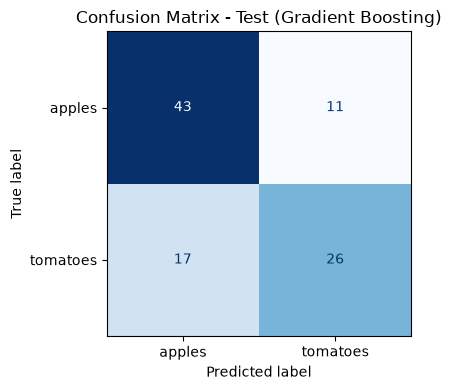

In [11]:
cm = confusion_matrix(y_test, y_test_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=["apples", "tomatoes"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title("Confusion Matrix - Test (Gradient Boosting)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_gradient.png", dpi=150)
plt.show()

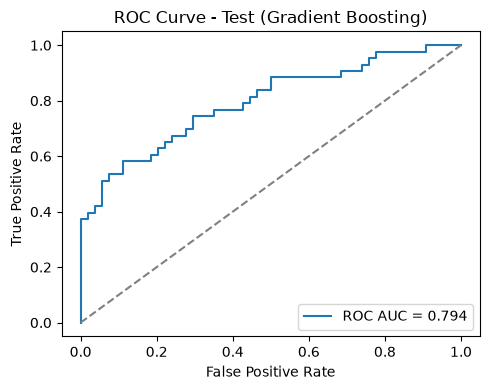

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
auc = roc_auc_score(y_test, y_test_prob)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f"ROC AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve - Test (Gradient Boosting)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curve_gradient.png", dpi=150)
plt.show()

## 9) Ważność cech (gradient boosting)

Wybrane cechy: 16 / 21 (po filtracji korelacji)


,feature,importance
3,glcm_correlation_d1,0.167079
1,glcm_homogeneity_d1,0.107867
11,hsv_h_std,0.105997
14,hsv_v_mean,0.103177
0,glcm_contrast_d1,0.095925
13,hsv_s_std,0.077485
12,hsv_s_mean,0.066095
2,glcm_energy_d1,0.052293
15,hsv_v_std,0.048854
5,shape_perimeter_norm,0.036185


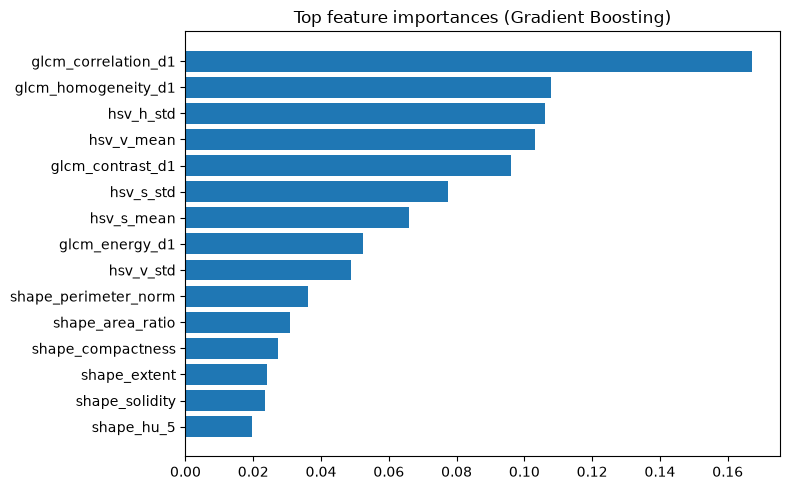

In [13]:
selector = final_model.named_steps["selector"]
gb = final_model.named_steps["clf"]

selected_idx = selector.get_support(indices=True)
selected_features = [feature_names_corr_train[i] for i in selected_idx]
importances = gb.feature_importances_

importance_df = pd.DataFrame(
    {
        "feature": selected_features,
        "importance": importances,
    }
).sort_values("importance", ascending=False)

print(f"Wybrane cechy: {len(selected_features)} / {len(feature_names_corr_train)} (po filtracji korelacji)")
display(importance_df.head(15))

fig, ax = plt.subplots(figsize=(8, 5))
top_n = min(15, len(importance_df))
plot_df = importance_df.head(top_n).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["importance"])
ax.set_title("Top feature importances (Gradient Boosting)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "feature_importance_gradient.png", dpi=150)
plt.show()

## 10) Wizualizacja PCA 2D wybranych cech

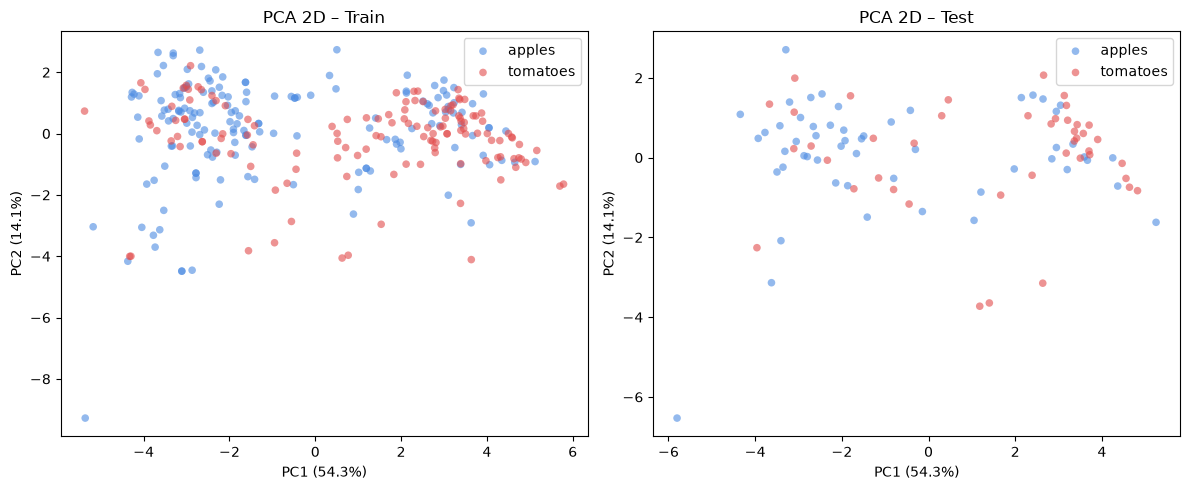

PCA wyjaśniona wariancja: PC1=54.3%, PC2=14.1%


In [14]:
scaler   = final_model.named_steps["scaler"]
selector = final_model.named_steps["selector"]

X_train_scaled   = scaler.transform(X_train_corr)
X_train_selected = selector.transform(X_train_scaled)
X_test_scaled    = scaler.transform(X_test_corr)
X_test_selected  = selector.transform(X_test_scaled)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_selected)
X_test_2d  = pca.transform(X_test_selected)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ["Train", "Test"]
datasets = [(X_train_2d, y_train), (X_test_2d, y_test)]
colors = {0: "#4C8BE2", 1: "#E24C4C"}
labels_map = {0: "apples", 1: "tomatoes"}

for ax, title, (X_2d, y) in zip(axes, titles, datasets):
    for cls in [0, 1]:
        mask = y == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors[cls], label=labels_map[cls],
                   alpha=0.6, s=30, edgecolors="none")
    ax.set_title(f"PCA 2D – {title}")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_2d_gradient.png", dpi=150)
plt.show()

print(f"PCA wyjaśniona wariancja: PC1={pca.explained_variance_ratio_[0]*100:.1f}%, "
      f"PC2={pca.explained_variance_ratio_[1]*100:.1f}%")

## 11) Błędne klasyfikacje

Błędnie sklasyfikowanych: 28 / 97


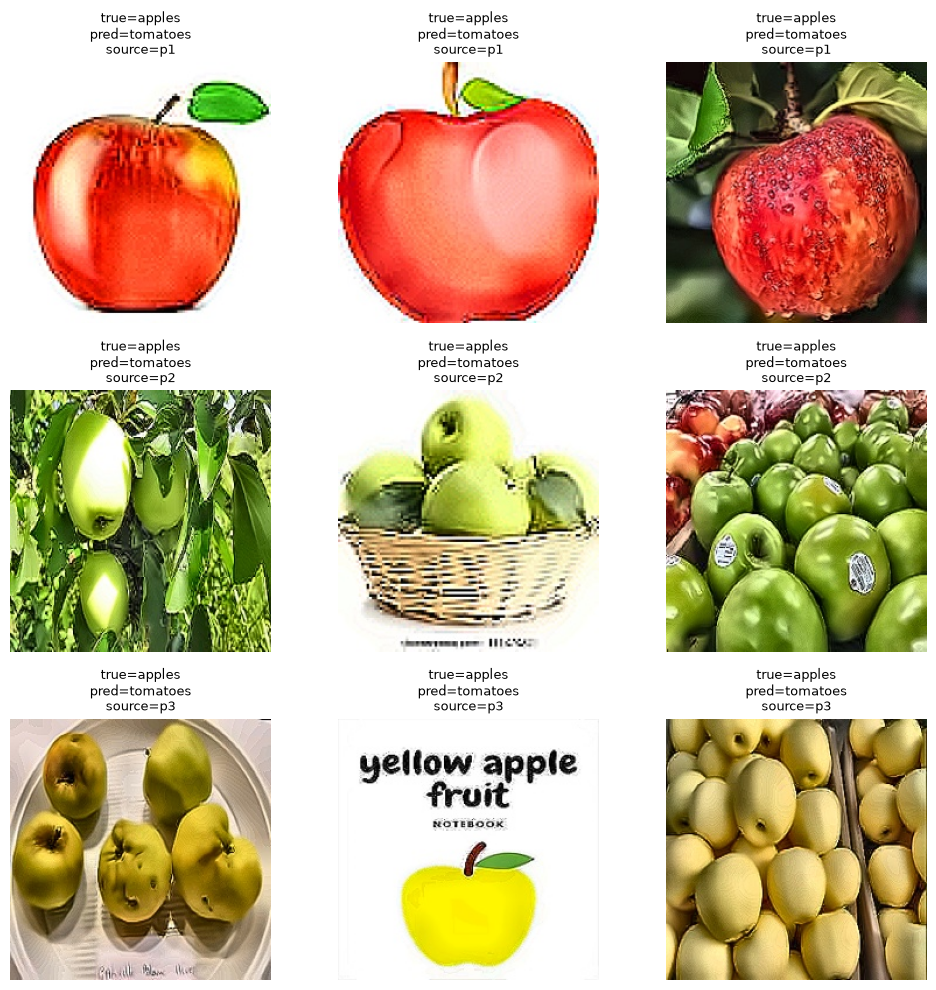

In [15]:
error_idx = np.where(y_test_pred != y_test)[0]
print(f"Błędnie sklasyfikowanych: {len(error_idx)} / {len(y_test)}")

show_n = min(9, len(error_idx))
if show_n == 0:
    print("Brak błędnych klasyfikacji.")
else:
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()
    for ax_idx, sample_idx in enumerate(error_idx[:show_n]):
        ax = axes[ax_idx]
        image = cv2.imread(test_df.iloc[sample_idx]["path"])
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        true_label = LABEL_TO_CLASS[int(y_test[sample_idx])]
        pred_label = LABEL_TO_CLASS[int(y_test_pred[sample_idx])]
        source = test_df.iloc[sample_idx]["source"]

        ax.imshow(image_rgb)
        ax.set_title(f"true={true_label}\npred={pred_label}\nsource={source}", fontsize=9)
        ax.axis("off")

    for ax in axes[show_n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "misclassified_gradient.png", dpi=150)
    plt.show()

## 12) Metryki per źródło (p1/p2/p3)

In [16]:
source_results = []
for source in sorted(test_df["source"].unique()):
    idx = np.where((test_df["source"] == source).to_numpy())[0]
    y_true_src = y_test[idx]
    y_pred_src = y_test_pred[idx]
    source_results.append({
        "source":   source,
        "count":    int(len(idx)),
        "accuracy": round(float(accuracy_score(y_true_src, y_pred_src)), 4),
        "f1_macro": round(float(f1_score(y_true_src, y_pred_src, average="macro")), 4),
    })

display(pd.DataFrame(source_results).sort_values("source"))

,source,count,accuracy,f1_macro
0,p1,47,0.8085,0.7756
1,p2,24,0.5833,0.5833
2,p3,26,0.6538,0.6533


## 13) Wnioski

- **Wynik na zbiorze testowym**: dokładność 0.71, f1_macro 0.70, ROC AUC 0.79. Gradient boosting daje wyniki podobne do SVM i Random Forest na tych samych cechach — żadna z metod nie jest wyraźnie lepsza.
- **Jabłka vs pomidory**: model lepiej rozpoznaje jabłka (recall 0.80) niż pomidory (recall 0.60). Częściej myli pomidory z jabłkami niż odwrotnie. Łącznie błędnie sklasyfikowanych jest 28 z 97 obrazów.
- **Najważniejsze cechy**: na górze listy są cechy tekstury z GLCM (`glcm_correlation_d1`, `glcm_homogeneity_d1`, `glcm_contrast_d1`) oraz cechy koloru z HSV (`hsv_h_std`, `hsv_v_mean`). Cechy kształtu (`shape_*`) mają najmniejsze znaczenie — o klasie decyduje głównie tekstura i kolor, a nie kształt.
- **Hiperparametry**: najlepsze okazały się `learning_rate=0.1`, `max_depth=3`, `n_estimators=300`, `subsample=0.8` oraz 16 wybranych cech. W porównaniu konfiguracji widać, że bardzo małe `learning_rate` (0.01) dawało gorszy wynik.
- **Próg decyzyjny**: dostrojony próg 0.435 poprawił f1 na walidacji, ale na zbiorze testowym nie pomógł (wynik nieco gorszy niż przy progu 0.50). To znak, że dostrojenie progu na małym zbiorze nie zawsze przenosi się na nowe dane.
- **Podział na źródła**: najlepiej wypada źródło p1 (dokładność 0.81), najgorzej p2 (0.58). Obrazy z p2 są dla modelu najtrudniejsze.
- **Ograniczenia**: zbiór testowy ma tylko 97 obrazów, więc do metryk trzeba podchodzić ostrożnie — kilka błędów więcej lub mniej zauważalnie zmienia wynik.
